> <div class = 'markdown-google-sans'>
> <h1>Neural Network Performance Improvement - Early Stopping using Callbacks</h1>
> <p>Early stopping is a technique used in deep learning to prevent overfitting and improve the performance of neural networks. It involves monitoring a specific performance metric during training and stopping the training process once the metric stops improving. </p>
> <p>In deep learning, a neural network is trained over multiple epochs, where each epoch is a complete pass through the training dataset. The model's performance is typically evaluated on a validation set to ensure that it generalizes well to unseen data. Early stopping is a method to halt training before it completes all epochs if the model's performance on the validation set starts to degrade or plateau.</p>

> ## Benefits of Early Stopping
> - Prevents Overfitting: By stopping training when performance on the validation set starts to decline, early stopping helps avoid overfitting to the training data.
<br><br>
> - Reduces Training Time: It saves computational resources and training time by stopping once further training no longer benefits model performance.
<br><br>
- Ensures Better Generalization: By restoring the best weights, early stopping ensures that the model you end up with is the one that performed best on the validation set, thus improving generalization.
</div>

In [72]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, Dense

In [73]:
X, y = make_circles(
    n_samples = 500,
    noise = 0.1,
    factor = 0.8,
    random_state = 42
)

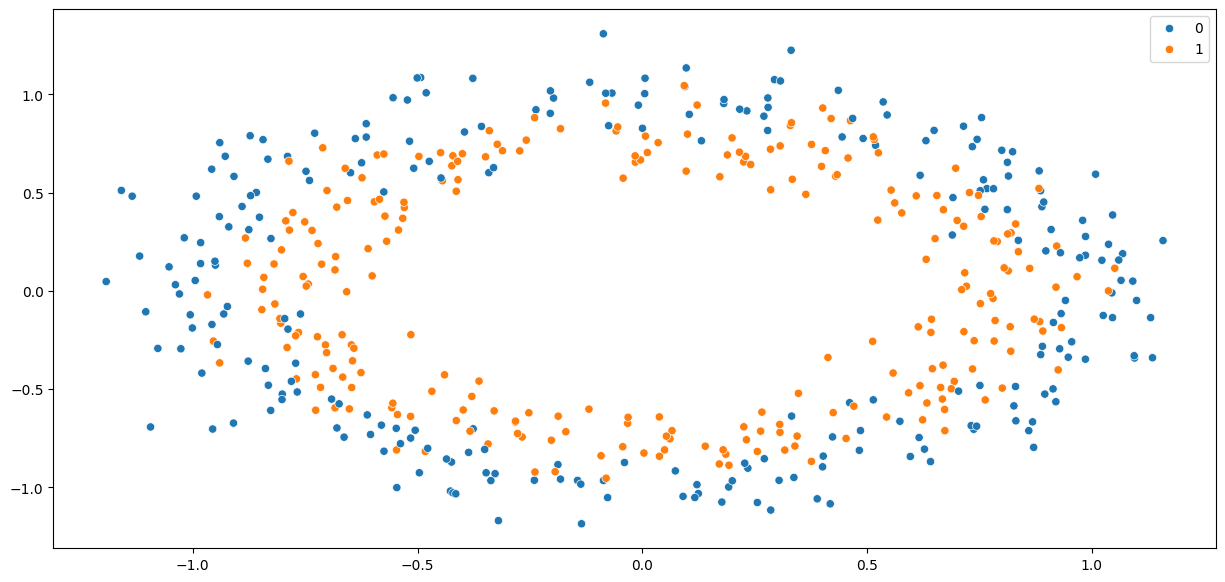

In [75]:
plt.figure(figsize = (15, 7))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue = y)
plt.show()

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [77]:
model = Sequential()

model.add(Input(shape = (X_train.shape[1],)))
model.add(Dense(units = 50, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                     │ (None, 50)                  │             150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 201 (804.00 B)

 Trainable params: 201 (804.00 B)

 Non-trainable params: 0 (0.00 B)

In [78]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [79]:
history = model.fit(X_train, y_train, epochs = 1000, verbose = 0, validation_data = (X_test, y_test))

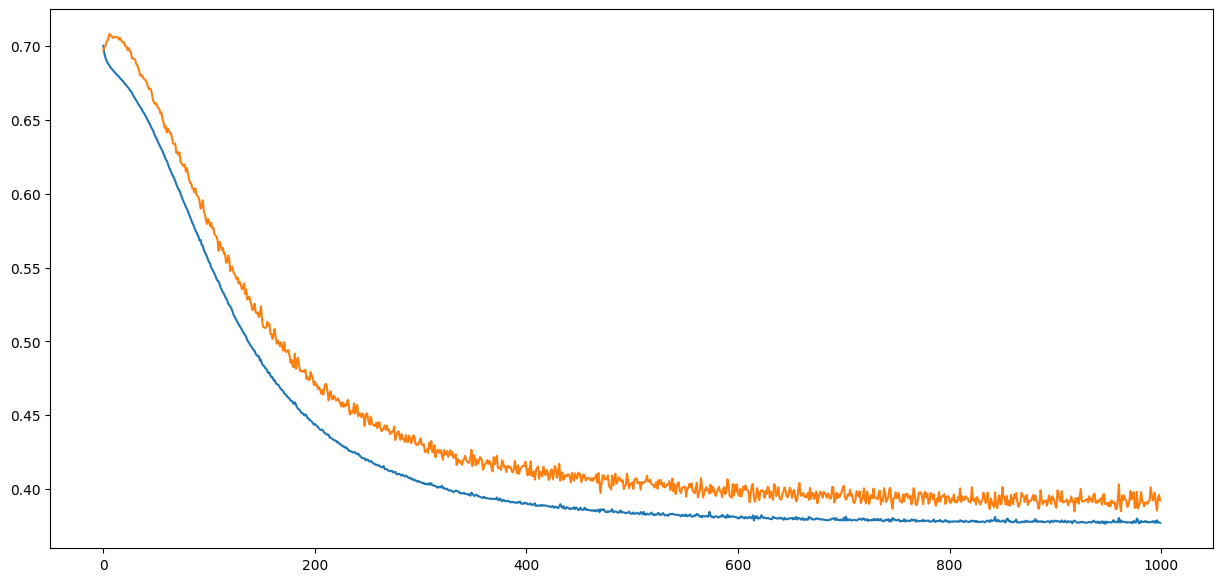

In [80]:
plt.figure(figsize = (15, 7))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

> <div class = 'markdown-google-sans'>
> <h1>Using Callbacks for Early Stopping</h1>
> <p>Callbacks are a feature provided by deep learning frameworks such as Keras or TensorFlow that allow you to hook into the training process. An early stopping callback automates the process of monitoring the metric and stopping training when appropriate. Here’s how you typically use early stopping with callbacks: </p>
>
> - nstantiate EarlyStopping Callback: You create an instance of the early stopping callback with parameters like the metric to monitor, patience, and whether to restore the best weights.
>
> - Pass to Training Method: You pass the early stopping callback to the model’s fit method (or equivalent training method in your framework). The callback then monitors the specified metric during training.


In [81]:
model = Sequential()

model.add(Input(shape = (X_train.shape[1],)))
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [82]:
model.compile(optimizer='Adam', loss = 'binary_crossentropy', metrics=['accuracy'])

In [83]:
from keras.callbacks import EarlyStopping

callback = EarlyStopping(
    monitor="val_loss", # on which entity you want to track and stop the iterations of trainings
    min_delta=0.00001, # The minimum difference between previous and current loss value
    patience=20, # number of further iterations after reaching min_delta
    verbose=1, # Show/Hide output
    mode="auto", # training will stop when the quantity monitored has stopped decreasing(min)/increasing(max)/auto
    baseline=None, # Baseline value for the monitored quantity.
    restore_best_weights=False # Whether to restore model weights from the epoch with the best value of the monitored quantity. If False, the model weights obtained at the last step of training are used.
)

In [84]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1000, callbacks=callback, verbose=0)

Epoch 182: early stopping


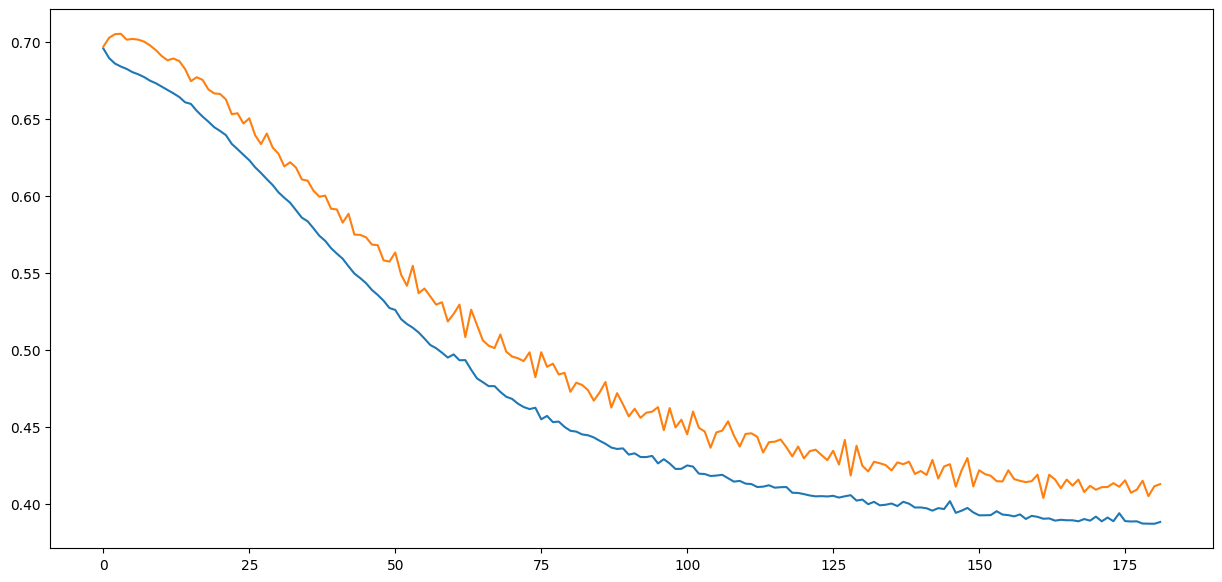

In [85]:
plt.figure(figsize = (15, 7))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()